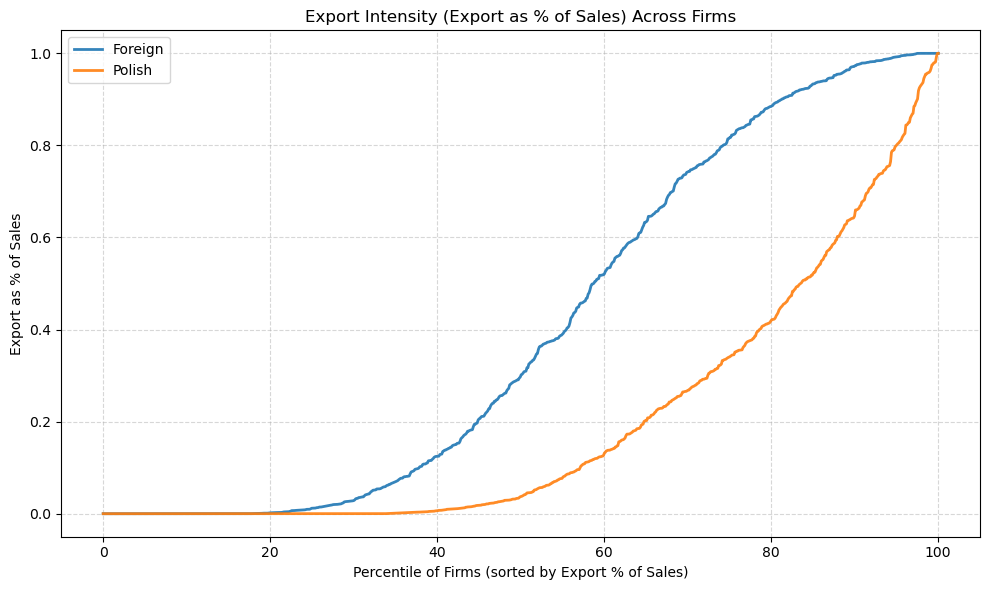

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_excel("Results/GRIP Analysis REGRESSION.xlsx")

export_col = "Export as % of Sales"

# Clean up
df[export_col] = pd.to_numeric(df[export_col], errors="coerce")
df = df.dropna(subset=[export_col, "P/F"])

# Sort by Export %
df = df.sort_values(by=export_col).reset_index(drop=True)

# Map categories
label_map = {"P": "Polish", "F": "Foreign"}
df["P/F_label"] = df["P/F"].map(label_map)

# --- Continuous line plot ---
plt.figure(figsize=(10,6))

# Plot each group separately to get smooth lines
for cat, sub in df.groupby("P/F_label"):
    plt.plot(
        np.linspace(0, 100, len(sub)),   # percentile axis
        sub[export_col].values,
        label=cat,
        linewidth=2,
        alpha=0.9
    )

plt.title("Export Intensity (Export as % of Sales) Across Firms")
plt.xlabel("Percentile of Firms (sorted by Export % of Sales)")
plt.ylabel("Export as % of Sales")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()


# --- Save figure ---
plt.savefig("Results/Export_Intensity_LineChart.png", dpi=300)
plt.show()


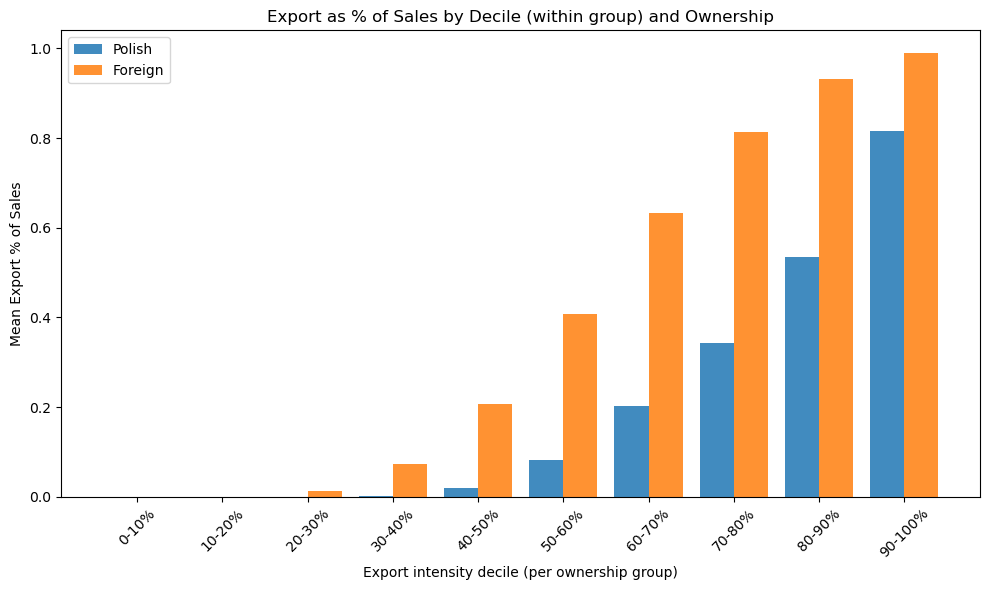

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# --- make deciles SEPARATELY for Polish and Foreign ---

parts = []
for group, sub in df.groupby("P/F"):
    sub = sub.sort_values(by=export_col).reset_index(drop=True)
    n = len(sub)
    # fixed 10 buckets 0..9
    sub["Export_decile"] = (sub.index / n * 10).astype(int)
    sub.loc[sub["Export_decile"] == 10, "Export_decile"] = 9
    parts.append(sub)

df_dec = pd.concat(parts, ignore_index=True)

# nice labels
df_dec["Export_decile_label"] = df_dec["Export_decile"].map(
    {i: f"{i*10}-{(i+1)*10}%" for i in range(10)}
)

# now take mean per group per OWN decile
summary = (
    df_dec.groupby(["P/F", "Export_decile_label"])[export_col]
          .mean()
          .reset_index()
)

# make sure bars appear in order 0..90
deciles = [f"{i*10}-{(i+1)*10}%" for i in range(10)]
label_map = {"P": "Polish", "F": "Foreign"}

plt.figure(figsize=(10, 6))
width = 0.4

for i, grp in enumerate(["P", "F"]):
    sub = summary[summary["P/F"] == grp].set_index("Export_decile_label").reindex(deciles)
    x_pos = [x + (i - 0.5) * width for x in range(len(deciles))]
    plt.bar(x_pos, sub[export_col].values, width=width,
            label=label_map.get(grp, grp), alpha=0.85)

plt.title("Export as % of Sales by Decile (within group) and Ownership")
plt.xlabel("Export intensity decile (per ownership group)")
plt.ylabel("Mean Export % of Sales")
plt.xticks(range(len(deciles)), deciles, rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig("Results/Export_Intensity_BarChart.png", dpi=300)
plt.show()


/var/folders/48/zcj75_4n65716ldn0j6mxb3m0000gn/T/ipykernel_55896/1830889967.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Export_band", "P/F"])


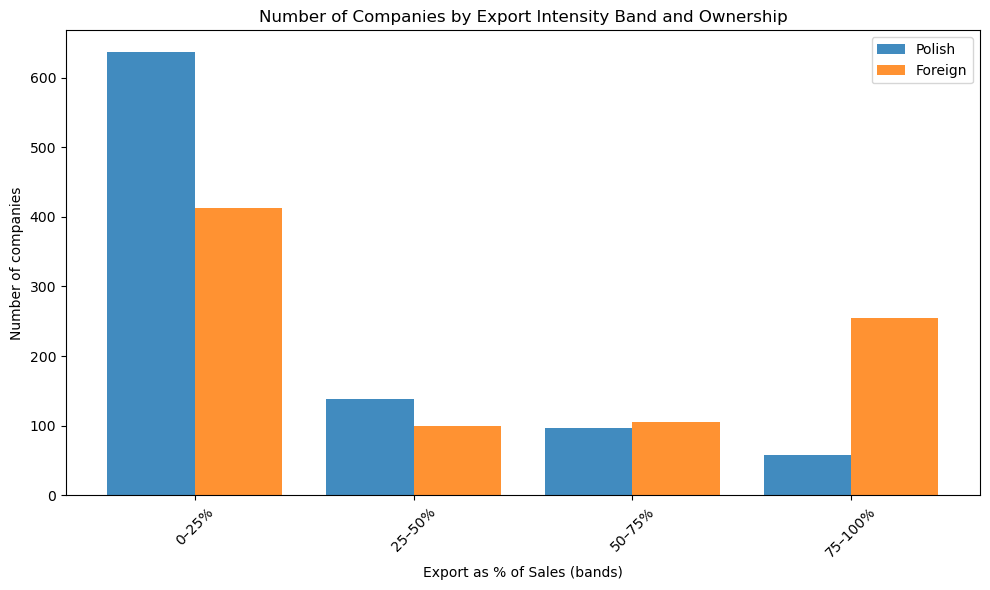

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load data (you already had df in memory, but keeping it explicit)
df = pd.read_excel("Results/GRIP Analysis REGRESSION.xlsx")

export_col = "Export as % of Sales"

# clean
df[export_col] = pd.to_numeric(df[export_col], errors="coerce")
df = df.dropna(subset=[export_col, "P/F"])

# cap exports at 100 so weird 120% etc. don’t create an extra bin
df[export_col] = df[export_col].clip(lower=0, upper=100)

# >>> CHANGE IS HERE: fixed 25% ranges instead of 10% bands <<<
bins = [0, 0.25, .50, .75, 1]
labels = ["0–25%", "25–50%", "50–75%", "75–100%"]

df["Export_band"] = pd.cut(
    df[export_col],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# count companies per band and ownership
counts = (
    df.groupby(["Export_band", "P/F"])
      .size()
      .reset_index(name="Count")
)

# make sure all bands present
bands_order = labels
label_map = {"P": "Polish", "F": "Foreign"}

plt.figure(figsize=(10, 6))
width = 0.4

for i, grp in enumerate(["P", "F"]):
    sub = counts[counts["P/F"] == grp].set_index("Export_band").reindex(bands_order).fillna(0)
    x_pos = [x + (i - 0.5) * width for x in range(len(bands_order))]
    plt.bar(
        x_pos,
        sub["Count"].values,
        width=width,
        label=label_map.get(grp, grp),
        alpha=0.85
    )

plt.title("Number of Companies by Export Intensity Band and Ownership")
plt.xlabel("Export as % of Sales (bands)")
plt.ylabel("Number of companies")
plt.xticks(range(len(bands_order)), bands_order, rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig("Results/Export_Intensity_Counts_By_Band.png", dpi=300)
plt.show()


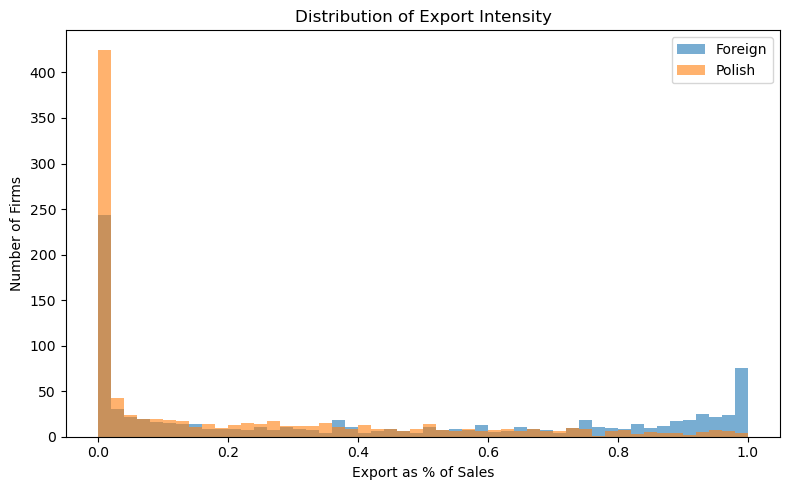

In [6]:
label_map = {"P": "Polish", "F": "Foreign"}
df["P/F_label"] = df["P/F"].map(label_map)

plt.figure(figsize=(8,5))
for cat, sub in df.groupby("P/F_label"):
    plt.hist(sub[export_col], bins=50, alpha=0.6, label=cat)

plt.title("Distribution of Export Intensity")
plt.xlabel("Export as % of Sales")
plt.ylabel("Number of Firms")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8,5))
df.boxplot(column=export_col, by="P/F_label", grid=False,
           showfliers=True, patch_artist=True,
           boxprops=dict(facecolor="lightgrey", color="black"),
           medianprops=dict(color="red", linewidth=2))

plt.title("Export Intensity (Export as % of Sales) by Ownership")
plt.suptitle("")  # remove pandas’ default title
plt.xlabel("Ownership Type")
plt.ylabel("Export as % of Sales")
plt.tight_layout()
plt.show()


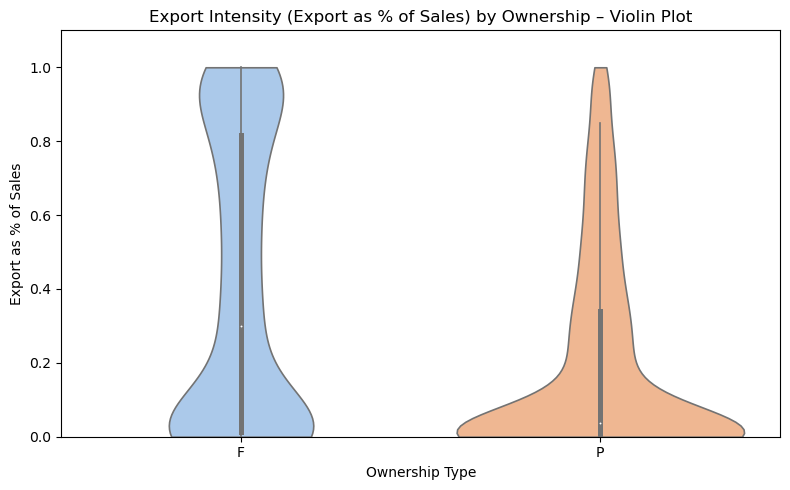

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="P/F",             # ownership type
    y=export_col,              # export intensity
    inner="box",               # show quartiles & median inside
    linewidth=1.2,
    palette="pastel",
    cut=0                      # <-- stops KDE from extending below 0 or above max
)

plt.title("Export Intensity (Export as % of Sales) by Ownership – Violin Plot")
plt.xlabel("Ownership Type")
plt.ylabel("Export as % of Sales")
plt.ylim(0, df[export_col].max() * 1.1)   # keep y-axis realistic
plt.tight_layout()
plt.show()


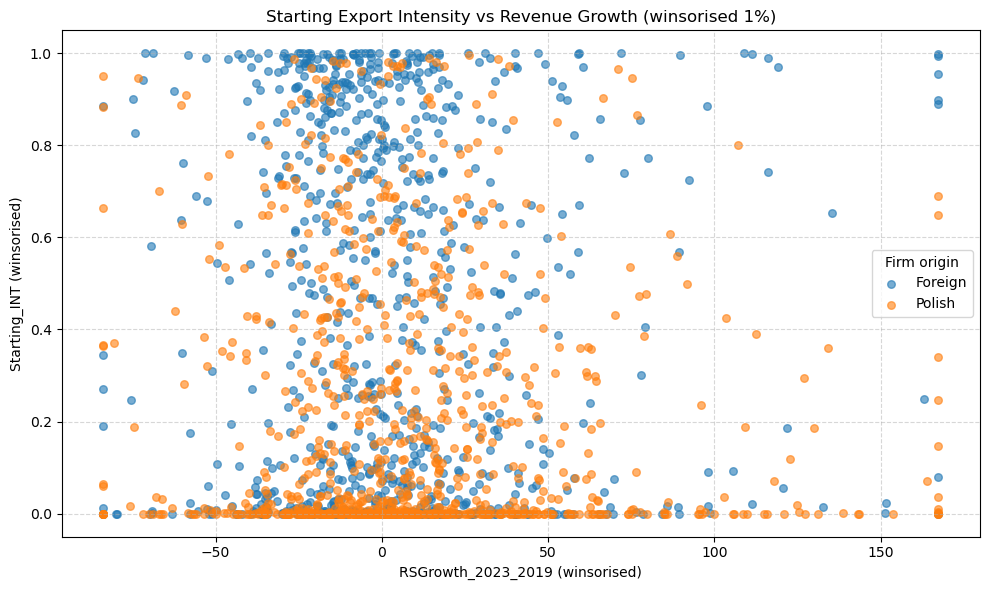

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mstats

# Load data
df = pd.read_excel("Results/GRIP Analysis REGRESSION.xlsx")

# Column names
x_col = "RSGrowth_2023_2019"
y_col = "Starting_INT"
pf_col = "P/F"

# Clean up numeric
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
df[y_col] = pd.to_numeric(df[y_col], errors="coerce")

# Drop missing
df_plot = df.dropna(subset=[x_col, y_col, pf_col]).copy()

# Category labels
label_map = {"P": "Polish", "F": "Foreign"}
df_plot["P/F_label"] = df_plot[pf_col].map(label_map)

# --- Winsorise 1% on both ends ---
df_plot["x_w"] = mstats.winsorize(df_plot[x_col], limits=[0.01, 0.01])
df_plot["y_w"] = mstats.winsorize(df_plot[y_col], limits=[0.0, 0.0])

# --- Scatter plot (winsorised) ---
plt.figure(figsize=(10, 6))

for cat, sub in df_plot.groupby("P/F_label"):
    plt.scatter(
        sub["x_w"],
        sub["y_w"],
        alpha=0.6,
        s=30,
        label=cat
    )

plt.title("Starting Export Intensity vs Revenue Growth (winsorised 1%)")
plt.xlabel("RSGrowth_2023_2019 (winsorised)")
plt.ylabel("Starting_INT (winsorised)")
plt.legend(title="Firm origin")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("Results/StartingINT_vs_RSGrowth_scatter_winsor.png", dpi=300)
plt.show()